## Project title and overview

# ✍️ Handwritten Digit Recognition
### A Custom Dataset, CNN Training & Deployment Project

**Qiyas AI and Data Science Program — Section 2**  
**Instructor:** Fantahun (PhD)

---

### 👥 Team Members

| # | Name | Student ID |
|---|------|------------|
| 1 | Sofiya Yasin | qiyas-2026-002375 |
| 2 | Megfira Surur | qiyas-2026-_____ |
| 3 | Medina | _____ |

---

## 📋 Project Overview

This project implements a complete handwritten digit recognition pipeline using a custom dataset collected from different people.

The project follows the required pipeline:

```text
RAW PHOTOS
   ↓
Quality Control
   ↓
Crop Digit
   ↓
Grayscale
   ↓
Lighting / Background Normalization
   ↓
Center Digit
   ↓
Resize → 32×32
   ↓
Normalize → [0,1]
   ↓
Train / Validation / Test Split
   ↓
Augmentation ONLY on Training
   ↓
Small CNN Training
   ↓
Evaluation on Untouched Test Set
   ↓
Deployment

In [5]:

import os
import glob
import hashlib
import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

np.random.seed(42)
tf.random.set_seed(42)

DATASET_DIR = "../digit_dataset"
IMG_SIZE = 32
CLASSES = [str(d) for d in range(10)]

print("TensorFlow:", tf.__version__)
print("OpenCV:", cv2.__version__)

TensorFlow: 2.21.0
OpenCV: 5.0.0


## Step 2 — Verify Dataset

In [6]:

print("Current working directory:")
print(os.getcwd())

print("\nDataset path:")
print(os.path.abspath(DATASET_DIR))

if not os.path.isdir(DATASET_DIR):
    raise FileNotFoundError(
        f"\nDataset folder was not found:\n{os.path.abspath(DATASET_DIR)}\n\n"
        "Make sure 'digit_dataset' is in the correct location."
    )

print("\nDataset folder found successfully! ✅")

print("\nDataset contents:")
print(sorted(os.listdir(DATASET_DIR)))

Current working directory:
C:\Users\Hello\Documents\ai_training_section_2\Deep Learning\digit_dataset

Dataset path:
C:\Users\Hello\Documents\ai_training_section_2\Deep Learning\digit_dataset

Dataset folder found successfully! ✅

Dataset contents:
['.ipynb_checkpoints', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'Untitled.ipynb', 'best_digit_cnn.keras', 'digit_dataset_preprocessed.npz', 'digit_recognition_model.keras', 'digit_recognition_project.ipynb', 'uploaded_digit.jpg']


## Step 3 — Verify Class Folders

In [7]:

missing_classes = []

for cls in CLASSES:
    folder = os.path.join(DATASET_DIR, cls)

    if os.path.isdir(folder):
        print(f"Digit {cls}: ✅ folder exists")
    else:
        print(f"Digit {cls}: ❌ folder missing")
        missing_classes.append(cls)

if missing_classes:
    raise FileNotFoundError(
        f"\nMissing digit folders: {missing_classes}"
    )

print("\nAll 10 digit folders are present! ✅")

Digit 0: ✅ folder exists
Digit 1: ✅ folder exists
Digit 2: ✅ folder exists
Digit 3: ✅ folder exists
Digit 4: ✅ folder exists
Digit 5: ✅ folder exists
Digit 6: ✅ folder exists
Digit 7: ✅ folder exists
Digit 8: ✅ folder exists
Digit 9: ✅ folder exists

All 10 digit folders are present! ✅


## Step 4 — Dataset Scan

In [9]:

def scan_dataset(dataset_dir):
    report = {
        "per_class_count": {},
        "corrupt_files": [],
        "resolutions": [],
        "total_files": 0
    }

    for cls in CLASSES:
        folder = os.path.join(dataset_dir, cls)

        # Include both .jpg and .JPG
        files = (
            glob.glob(os.path.join(folder, "*.jpg")) +
            glob.glob(os.path.join(folder, "*.JPG"))
        )

        report["per_class_count"][cls] = len(files)
        report["total_files"] += len(files)

        for file_path in files:
            img = cv2.imread(file_path)

            if img is None:
                report["corrupt_files"].append(file_path)
            else:
                report["resolutions"].append(img.shape[:2])

    return report


report = scan_dataset(DATASET_DIR)

print("Images per class:")
print("-" * 30)

for cls, count in report["per_class_count"].items():
    print(f"Digit {cls}: {count}")

print("-" * 30)
print("Total images:", report["total_files"])
print("Corrupt/unreadable images:", len(report["corrupt_files"]))

if report["corrupt_files"]:
    print("\nCorrupt files:")
    for file_path in report["corrupt_files"]:
        print(" ", file_path)

# Resolution statistics
if report["resolutions"]:
    resolutions = np.array(report["resolutions"])

    print("\nResolution statistics:")
    print("Minimum (H, W):", resolutions.min(axis=0))
    print("Maximum (H, W):", resolutions.max(axis=0))
    print("Mean (H, W):", resolutions.mean(axis=0).round(1))

Images per class:
------------------------------
Digit 0: 100
Digit 1: 100
Digit 2: 160
Digit 3: 100
Digit 4: 160
Digit 5: 160
Digit 6: 140
Digit 7: 100
Digit 8: 100
Digit 9: 100
------------------------------
Total images: 1220
Corrupt/unreadable images: 0

Resolution statistics:
Minimum (H, W): [66 86]
Maximum (H, W): [4096 4096]
Mean (H, W): [1564.9 1281.3]


## Step 5 — Check Dataset Requirement

In [11]:

print("Checking the instructor's requirement:")
print("Requirement: 50–100 images for EACH digit\n")

requirement_ok = True

for cls, count in report["per_class_count"].items():

    if 50 <= count <= 200:
        status = "✅"
    else:
        status = "❌"
        requirement_ok = False

    print(f"Digit {cls}: {count:3d} images {status}")

print("\nTotal images:", report["total_files"])

if requirement_ok:
    print("\n✅ Every digit satisfies the 50–100 image requirement.")
else:
    print("\n⚠️ At least one digit is outside the required range.")

Checking the instructor's requirement:
Requirement: 50–100 images for EACH digit

Digit 0: 100 images ✅
Digit 1: 100 images ✅
Digit 2: 160 images ✅
Digit 3: 100 images ✅
Digit 4: 160 images ✅
Digit 5: 160 images ✅
Digit 6: 140 images ✅
Digit 7: 100 images ✅
Digit 8: 100 images ✅
Digit 9: 100 images ✅

Total images: 1220

✅ Every digit satisfies the 50–100 image requirement.


## Step 6 — Visualize Raw Images

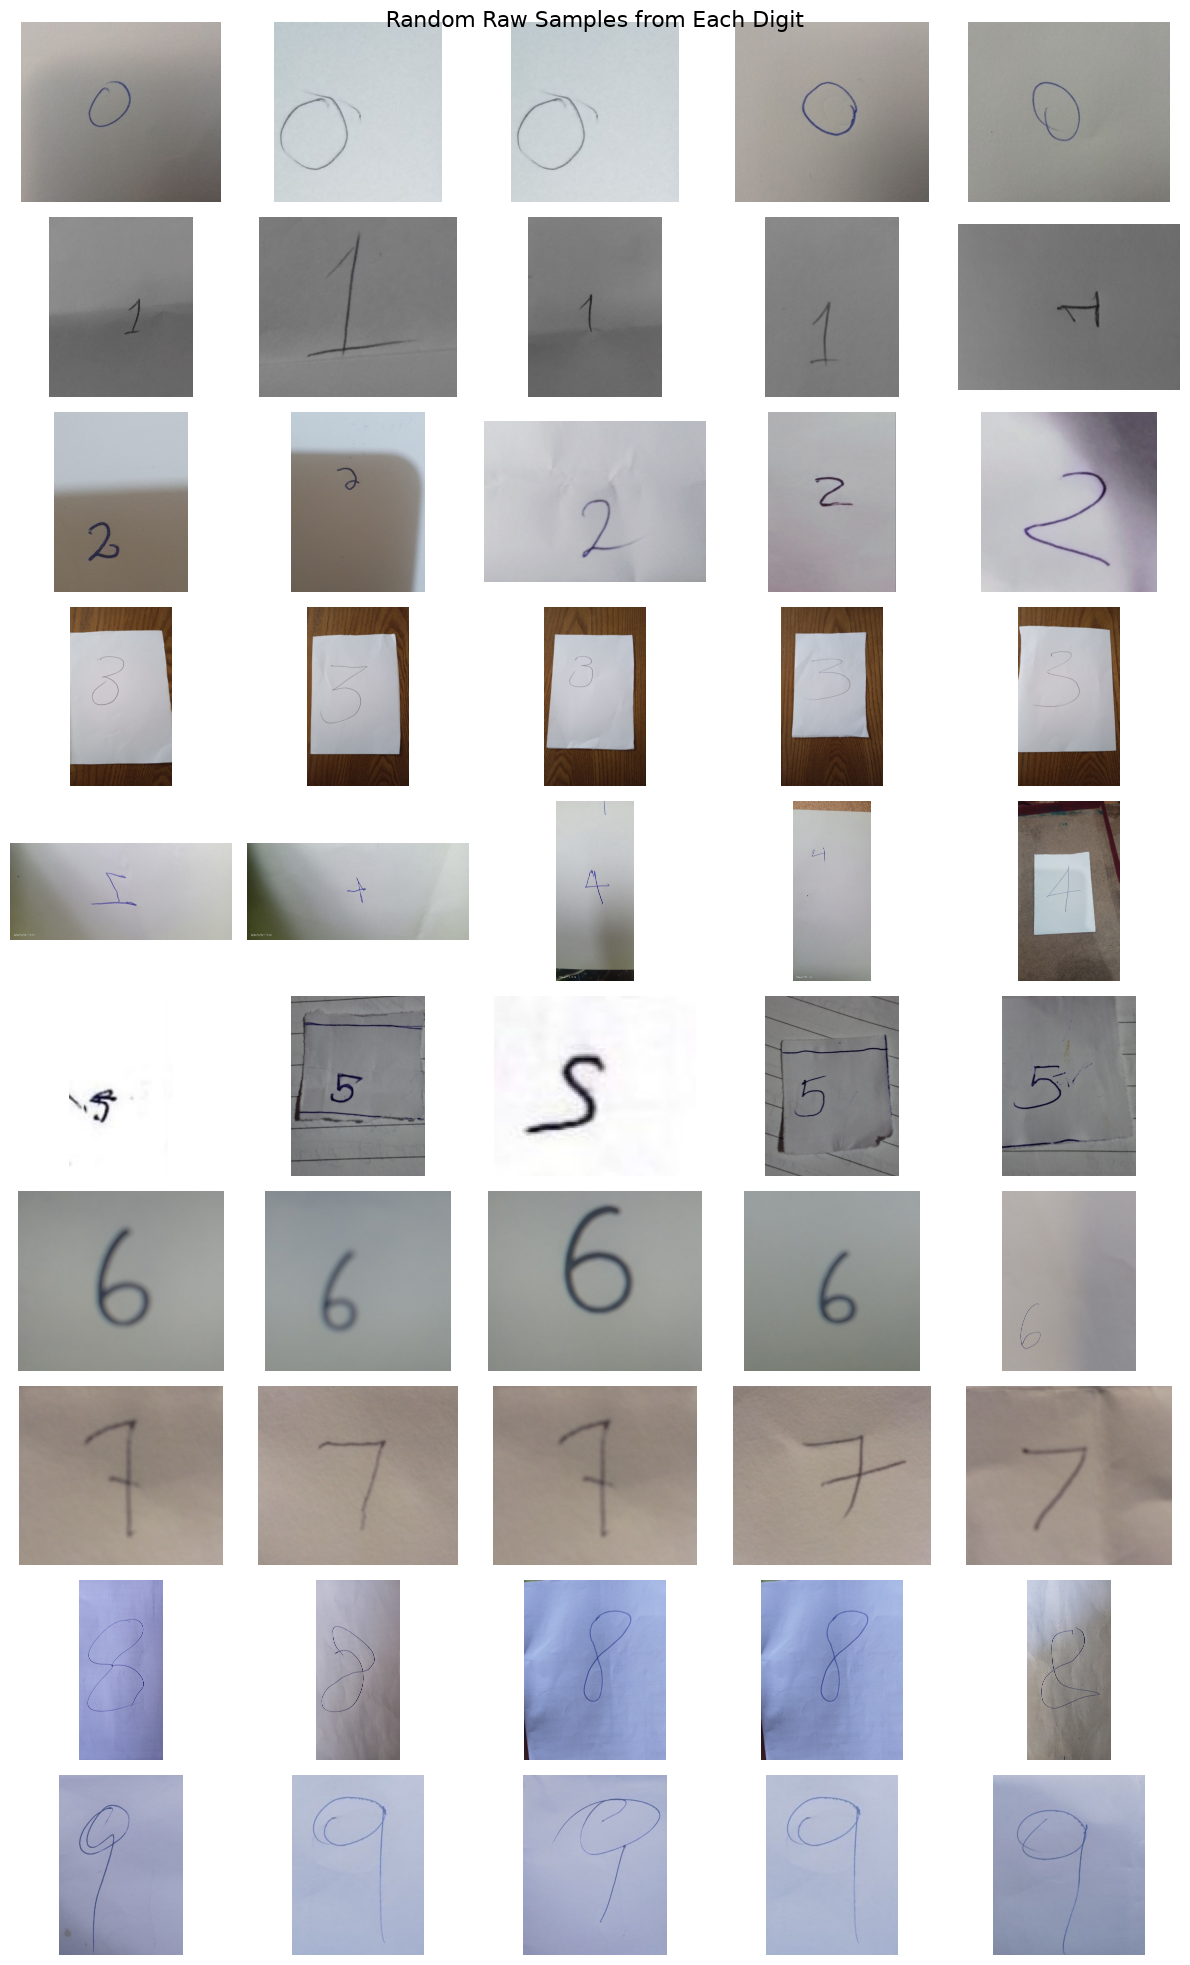

In [13]:
import random
def show_raw_samples(dataset_dir, n_per_class=5, seed=42):

    rng = random.Random(seed)

    fig, axes = plt.subplots(
        len(CLASSES),
        n_per_class,
        figsize=(12, 20)
    )

    for row, cls in enumerate(CLASSES):

        files = (
            glob.glob(os.path.join(dataset_dir, cls, "*.jpg")) +
            glob.glob(os.path.join(dataset_dir, cls, "*.JPG"))
        )

        rng.shuffle(files)
        files = files[:n_per_class]

        for col in range(n_per_class):

            ax = axes[row, col]
            ax.axis("off")

            if col < len(files):

                img = cv2.imread(files[col])
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

                ax.imshow(img)

            if col == 0:
                ax.set_ylabel(
                    f"Digit {cls}",
                    rotation=0,
                    labelpad=35,
                    fontsize=11
                )

    plt.suptitle(
        "Random Raw Samples from Each Digit",
        fontsize=16
    )

    plt.tight_layout()
    plt.show()


show_raw_samples(DATASET_DIR, n_per_class=5)

## Step 7 — Detect Suspicious Images

In [14]:

def laplacian_blur_score(img_gray):
    """
    Higher score generally means a sharper image.
    This is only a screening tool, not an automatic
    decision that an image is bad.
    """
    return cv2.Laplacian(
        img_gray,
        cv2.CV_64F
    ).var()


def find_suspicious_images(dataset_dir, blur_threshold=50.0):

    blurry = []
    duplicates = []

    seen_hashes = {}

    for cls in CLASSES:

        files = (
            glob.glob(os.path.join(dataset_dir, cls, "*.jpg")) +
            glob.glob(os.path.join(dataset_dir, cls, "*.JPG"))
        )

        for file_path in files:

            img = cv2.imread(file_path)

            if img is None:
                continue

            gray = cv2.cvtColor(
                img,
                cv2.COLOR_BGR2GRAY
            )

            score = laplacian_blur_score(gray)

            if score < blur_threshold:
                blurry.append(
                    (file_path, round(score, 2))
                )

            # Hash file for exact duplicate detection
            with open(file_path, "rb") as f:
                file_hash = hashlib.md5(
                    f.read()
                ).hexdigest()

            if file_hash in seen_hashes:
                duplicates.append(
                    (file_path, seen_hashes[file_hash])
                )
            else:
                seen_hashes[file_hash] = file_path

    return blurry, duplicates


blurry, duplicates = find_suspicious_images(
    DATASET_DIR,
    blur_threshold=50.0
)

print(f"Potentially blurry images: {len(blurry)}")

for file_path, score in blurry[:30]:
    print(f"{score:8.2f}  {file_path}")

if len(blurry) > 30:
    print(f"... and {len(blurry) - 30} more")


print("\nExact duplicate files:", len(duplicates))

for duplicate, original in duplicates[:30]:
    print(f"{duplicate}")
    print(f"  duplicate of → {original}")

Potentially blurry images: 844
   26.53  ../digit_dataset\0\0_001.jpg
   10.33  ../digit_dataset\0\0_002.jpg
   23.28  ../digit_dataset\0\0_003.jpg
   28.94  ../digit_dataset\0\0_004.jpg
    7.69  ../digit_dataset\0\0_007.jpg
   39.66  ../digit_dataset\0\0_008.jpg
   44.80  ../digit_dataset\0\0_010.jpg
   20.62  ../digit_dataset\0\0_011.jpg
    8.42  ../digit_dataset\0\0_012.jpg
   10.03  ../digit_dataset\0\0_013.jpg
   41.00  ../digit_dataset\0\0_014.jpg
    8.33  ../digit_dataset\0\0_015.jpg
   42.14  ../digit_dataset\0\0_016.jpg
   49.35  ../digit_dataset\0\0_017.jpg
   34.40  ../digit_dataset\0\0_018.jpg
   33.98  ../digit_dataset\0\0_019.jpg
   45.55  ../digit_dataset\0\0_020.jpg
   29.43  ../digit_dataset\0\0_022.jpg
   26.13  ../digit_dataset\0\0_023.jpg
   18.64  ../digit_dataset\0\0_024.jpg
   43.49  ../digit_dataset\0\0_025.jpg
   43.33  ../digit_dataset\0\0_026.jpg
   34.53  ../digit_dataset\0\0_027.jpg
   38.69  ../digit_dataset\0\0_028.jpg
   30.89  ../digit_dataset\0\0_02

## Step 8 — Preprocessing Functions

In [15]:

def find_paper_region(gray):
    """
    Try to locate the paper/background region.
    Returns (x0, y0, x1, y1) or None.
    """

    blur = cv2.GaussianBlur(
        gray,
        (5, 5),
        0
    )

    _, mask = cv2.threshold(
        blur,
        0,
        255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    contours, _ = cv2.findContours(
        mask,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    if not contours:
        return None

    largest = max(
        contours,
        key=cv2.contourArea
    )

    image_area = gray.shape[0] * gray.shape[1]

    if cv2.contourArea(largest) < image_area * 0.15:
        return None

    x, y, w, h = cv2.boundingRect(largest)

    # Small inward margin
    sx = int(w * 0.05)
    sy = int(h * 0.05)

    x0 = x + sx
    y0 = y + sy
    x1 = x + w - sx
    y1 = y + h - sy

    return x0, y0, x1, y1


def crop_digit(img_bgr, pad=15):

    gray_full = cv2.cvtColor(
        img_bgr,
        cv2.COLOR_BGR2GRAY
    )

    # ----------------------------------------
    # Stage 1: Find paper
    # ----------------------------------------

    paper_box = find_paper_region(gray_full)

    if paper_box is not None:

        x0, y0, x1, y1 = paper_box

        paper_bgr = img_bgr[
            y0:y1,
            x0:x1
        ]

        paper_gray = gray_full[
            y0:y1,
            x0:x1
        ]

    else:

        paper_bgr = img_bgr
        paper_gray = gray_full

    # ----------------------------------------
    # Stage 2: Find digit
    # ----------------------------------------

    blur = cv2.GaussianBlur(
        paper_gray,
        (5, 5),
        0
    )

    thresh = cv2.adaptiveThreshold(
        blur,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV,
        35,
        10
    )

    kernel = np.ones(
        (3, 3),
        np.uint8
    )

    thresh = cv2.morphologyEx(
        thresh,
        cv2.MORPH_OPEN,
        kernel,
        iterations=1
    )

    thresh = cv2.dilate(
        thresh,
        kernel,
        iterations=2
    )

    contours, _ = cv2.findContours(
        thresh,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    # Remove very small noise
    contours = [
        c for c in contours
        if cv2.contourArea(c) > 20
    ]

    if not contours:
        return paper_bgr

    xs, ys, xe, ye = [], [], [], []

    for c in contours:

        x, y, w, h = cv2.boundingRect(c)

        xs.append(x)
        ys.append(y)
        xe.append(x + w)
        ye.append(y + h)

    x0d = max(min(xs) - pad, 0)
    y0d = max(min(ys) - pad, 0)

    x1d = min(
        max(xe) + pad,
        paper_bgr.shape[1]
    )

    y1d = min(
        max(ye) + pad,
        paper_bgr.shape[0]
    )

    return paper_bgr[
        y0d:y1d,
        x0d:x1d
    ]


def normalize_lighting(gray_img):

    clahe = cv2.createCLAHE(
        clipLimit=3.0,
        tileGridSize=(8, 8)
    )

    return clahe.apply(gray_img)


def center_digit(gray_img):

    blur = cv2.GaussianBlur(
        gray_img,
        (5, 5),
        0
    )

    thresh = cv2.adaptiveThreshold(
        blur,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV,
        35,
        10
    )

    M = cv2.moments(thresh)

    if M["m00"] == 0:
        return gray_img

    cx = M["m10"] / M["m00"]
    cy = M["m01"] / M["m00"]

    h, w = gray_img.shape

    shift_x = w / 2 - cx
    shift_y = h / 2 - cy

    transformation = np.float32([
        [1, 0, shift_x],
        [0, 1, shift_y]
    ])

    centered = cv2.warpAffine(
        gray_img,
        transformation,
        (w, h),
        borderValue=255
    )

    return centered

## Step 9 — Complete Preprocessing Pipeline

In [16]:

def preprocess_image(
    path,
    img_size=IMG_SIZE
):
    """
    Preprocessing pipeline:

    Raw image
        ↓
    Crop digit
        ↓
    Grayscale
        ↓
    Lighting normalization
        ↓
    Center digit
        ↓
    Resize to 32x32
        ↓
    Normalize to [0,1]
    """

    img = cv2.imread(path)

    if img is None:
        return None

    # 1. Crop
    cropped = crop_digit(img)

    # 2. Grayscale
    gray = cv2.cvtColor(
        cropped,
        cv2.COLOR_BGR2GRAY
    )

    # 3. Lighting/background normalization
    normalized_lighting = normalize_lighting(gray)

    # 4. Center
    centered = center_digit(
        normalized_lighting
    )

    # 5. Resize
    resized = cv2.resize(
        centered,
        (img_size, img_size),
        interpolation=cv2.INTER_AREA
    )

    # 6. Normalize [0,1]
    normalized = (
        resized.astype("float32") / 255.0
    )

    return normalized

## Step 10 — Inspect Preprocessing

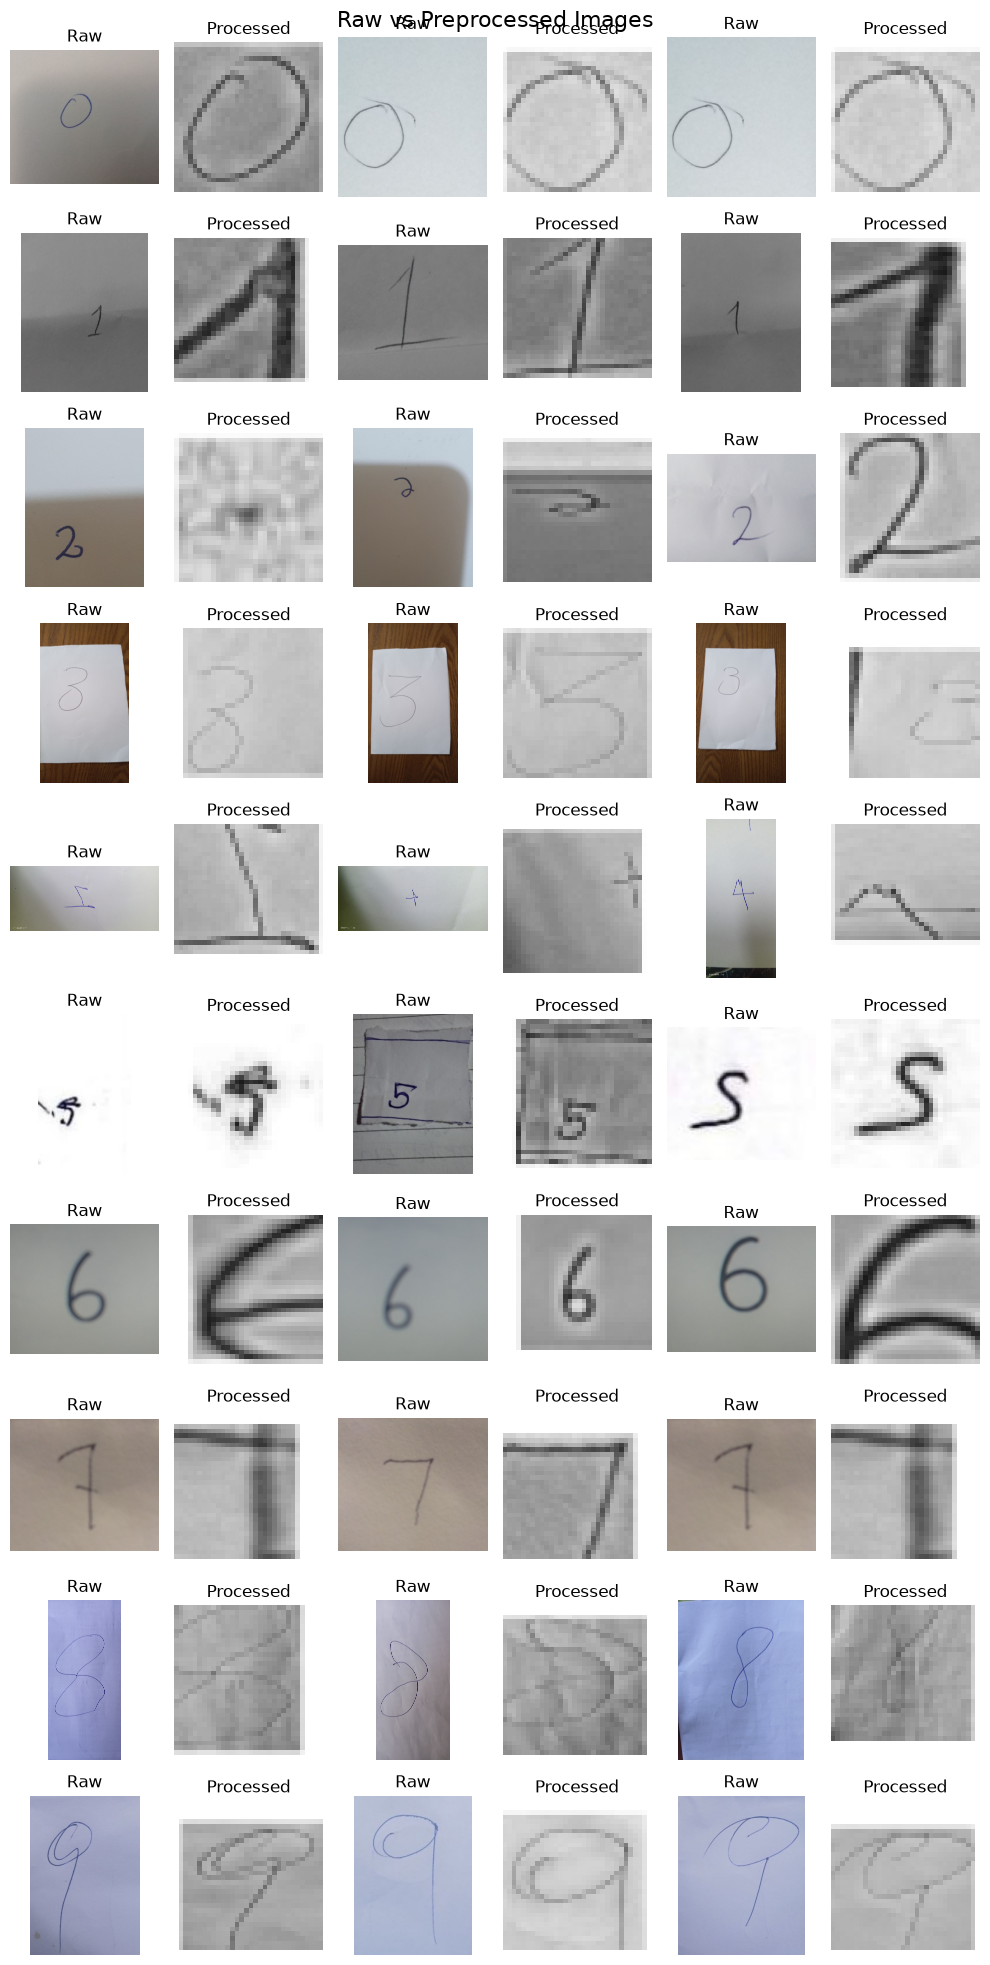

In [17]:
def show_preprocessing_examples(
    dataset_dir,
    n_per_class=3,
    seed=42
):

    rng = random.Random(seed)

    fig, axes = plt.subplots(
        len(CLASSES),
        n_per_class * 2,
        figsize=(10, 20)
    )

    for row, cls in enumerate(CLASSES):

        files = (
            glob.glob(
                os.path.join(
                    dataset_dir,
                    cls,
                    "*.jpg"
                )
            )
            +
            glob.glob(
                os.path.join(
                    dataset_dir,
                    cls,
                    "*.JPG"
                )
            )
        )

        rng.shuffle(files)

        files = files[:n_per_class]

        for col in range(n_per_class):

            if col >= len(files):
                continue

            path = files[col]

            # Raw
            raw = cv2.imread(path)
            raw = cv2.cvtColor(
                raw,
                cv2.COLOR_BGR2RGB
            )

            # Processed
            processed = preprocess_image(path)

            raw_ax = axes[row, col * 2]
            processed_ax = axes[row, col * 2 + 1]

            raw_ax.imshow(raw)
            raw_ax.axis("off")
            raw_ax.set_title("Raw")

            processed_ax.imshow(
                processed,
                cmap="gray",
                vmin=0,
                vmax=1
            )
            processed_ax.axis("off")
            processed_ax.set_title("Processed")

        axes[row, 0].set_ylabel(
            f"Digit {cls}",
            rotation=0,
            labelpad=35
        )

    plt.suptitle(
        "Raw vs Preprocessed Images",
        fontsize=16
    )

    plt.tight_layout()
    plt.show()


show_preprocessing_examples(
    DATASET_DIR,
    n_per_class=3
)

## Step 11 — Build X and y

In [18]:
X = []
y = []
skipped = []

for cls in CLASSES:

    files = (
        glob.glob(
            os.path.join(
                DATASET_DIR,
                cls,
                "*.jpg"
            )
        )
        +
        glob.glob(
            os.path.join(
                DATASET_DIR,
                cls,
                "*.JPG"
            )
        )
    )

    files = sorted(files)

    for file_path in files:

        processed = preprocess_image(file_path)

        if processed is None:
            skipped.append(file_path)
            continue

        X.append(processed)
        y.append(int(cls))


X = np.array(
    X,
    dtype="float32"
)

y = np.array(
    y,
    dtype="int64"
)

# Add CNN channel dimension
X = X.reshape(
    -1,
    IMG_SIZE,
    IMG_SIZE,
    1
)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Skipped:", len(skipped))

print("\nPixel range:")
print("Minimum:", X.min())
print("Maximum:", X.max())

X shape: (1220, 32, 32, 1)
y shape: (1220,)
Skipped: 0

Pixel range:
Minimum: 0.05882353
Maximum: 1.0


In [21]:
# Dataset configuration
NUM_CLASSES = 10
CLASSES = [str(d) for d in range(NUM_CLASSES)]

## Step 12 — Verify Processed Dataset

In [22]:
print("Processed class distribution:")
print("-" * 30)

for digit in range(NUM_CLASSES):

    count = int(
        np.sum(y == digit)
    )

    print(
        f"Digit {digit}: {count}"
    )

print("-" * 30)
print("Total:", len(y))

Processed class distribution:
------------------------------
Digit 0: 100
Digit 1: 100
Digit 2: 160
Digit 3: 100
Digit 4: 160
Digit 5: 160
Digit 6: 140
Digit 7: 100
Digit 8: 100
Digit 9: 100
------------------------------
Total: 1220


## Step 13 — Save Preprocessed Dataset

In [ ]:
PREPROCESSED_FILE = (
    "digit_dataset_preprocessed.npz"
)

np.savez_compressed(
    PREPROCESSED_FILE,
    X=X,
    y=y
)

print(
    f"Saved preprocessed dataset to: "
    f"{PREPROCESSED_FILE}"
)

## Step 14 — Train / Validation / Test Spli

In [24]:
SEED = 42

# First: separate 15% test data
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=0.15,
    stratify=y,
    random_state=SEED
)

# Second: take 15% of the total as validation
# Since 15% of the remaining 85% ≈ 12.75% total,
# use 0.1765 to obtain approximately 15% total validation.
validation_fraction = 0.15 / 0.85

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=validation_fraction,
    stratify=y_train_val,
    random_state=SEED
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

print("\nApproximate percentages:")
total = len(X)

print(
    f"Train: {len(X_train)/total:.2%}"
)

print(
    f"Validation: {len(X_val)/total:.2%}"
)

print(
    f"Test: {len(X_test)/total:.2%}"
)

Train: (854, 32, 32, 1)
Validation: (183, 32, 32, 1)
Test: (183, 32, 32, 1)

Approximate percentages:
Train: 70.00%
Validation: 15.00%
Test: 15.00%


## Step 15 — Class Distribution

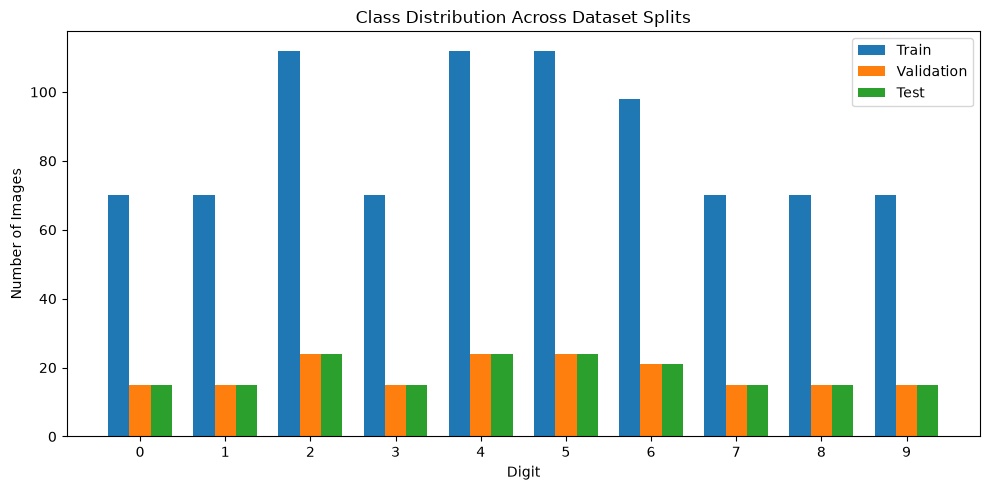

Train: [70, 70, 112, 70, 112, 112, 98, 70, 70, 70]
Validation: [15, 15, 24, 15, 24, 24, 21, 15, 15, 15]
Test: [15, 15, 24, 15, 24, 24, 21, 15, 15, 15]


In [25]:

def get_class_counts(labels):

    return [
        int(np.sum(labels == digit))
        for digit in range(NUM_CLASSES)
    ]


train_counts = get_class_counts(y_train)
val_counts = get_class_counts(y_val)
test_counts = get_class_counts(y_test)

x = np.arange(NUM_CLASSES)
width = 0.25

plt.figure(figsize=(10, 5))

plt.bar(
    x - width,
    train_counts,
    width,
    label="Train"
)

plt.bar(
    x,
    val_counts,
    width,
    label="Validation"
)

plt.bar(
    x + width,
    test_counts,
    width,
    label="Test"
)

plt.xticks(
    x,
    CLASSES
)

plt.xlabel("Digit")
plt.ylabel("Number of Images")
plt.title("Class Distribution Across Dataset Splits")
plt.legend()

plt.tight_layout()
plt.show()

print("Train:", train_counts)
print("Validation:", val_counts)
print("Test:", test_counts)

## Step 16 — Test Set Protection

In [26]:
assert (
    len(X_train)
    + len(X_val)
    + len(X_test)
    == len(X)
)

print(
    "✅ Train + Validation + Test "
    "contains all original samples."
)

print(
    "✅ Test set has been separated "
    "before augmentation."
)

print(
    "⚠️ Do not use X_test/y_test for "
    "model tuning."
)

✅ Train + Validation + Test contains all original samples.
✅ Test set has been separated before augmentation.
⚠️ Do not use X_test/y_test for model tuning.


## Step 17 — Training Augmentation

In [27]:
train_datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.10,
    shear_range=5,
    fill_mode="constant",
    cval=1.0
)

BATCH_SIZE = 32

train_generator = train_datagen.flow(
    X_train,
    y_train,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

print("Training augmentation created. ✅")
print("Validation data: NOT augmented.")
print("Test data: NOT augmented.")

Training augmentation created. ✅
Validation data: NOT augmented.
Test data: NOT augmented.


## Step 18 — Augmentation Preview

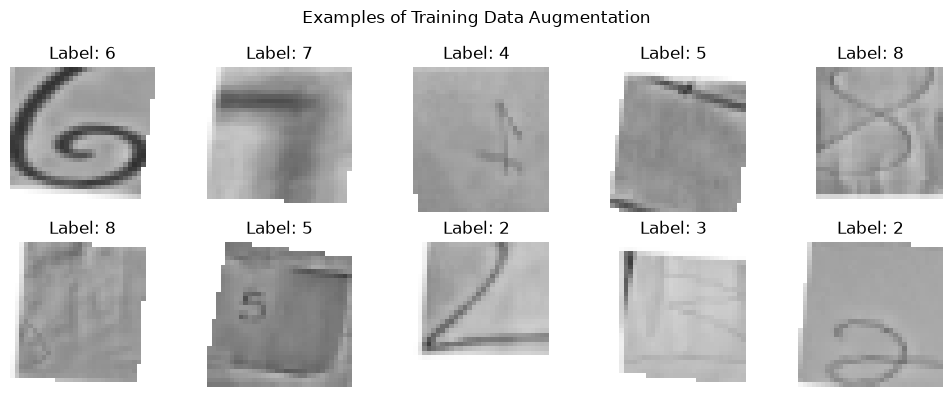

In [28]:
augmented_images, augmented_labels = next(
    train_generator
)

fig, axes = plt.subplots(
    2,
    5,
    figsize=(10, 4)
)

for i, ax in enumerate(axes.flat):

    ax.imshow(
        augmented_images[i].squeeze(),
        cmap="gray",
        vmin=0,
        vmax=1
    )

    ax.set_title(
        f"Label: {augmented_labels[i]}"
    )

    ax.axis("off")

plt.suptitle(
    "Examples of Training Data Augmentation"
)

plt.tight_layout()
plt.show()

## Step 19 — Small CNN

In [29]:
def build_small_cnn(
    input_shape=(32, 32, 1),
    num_classes=10,
    dropout=0.4,
    filters=(16, 32),
    learning_rate=1e-3
):

    model = models.Sequential([
        
        layers.Input(shape=input_shape),

        # Convolution block 1
        layers.Conv2D(
            filters[0],
            (3, 3),
            activation="relu",
            padding="same"
        ),

        layers.BatchNormalization(),

        layers.MaxPooling2D(
            (2, 2)
        ),

        # Convolution block 2
        layers.Conv2D(
            filters[1],
            (3, 3),
            activation="relu",
            padding="same"
        ),

        layers.BatchNormalization(),

        layers.MaxPooling2D(
            (2, 2)
        ),

        # Classification
        layers.Flatten(),

        layers.Dense(
            64,
            activation="relu"
        ),

        layers.Dropout(dropout),

        layers.Dense(
            num_classes,
            activation="softmax"
        )
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=learning_rate
        ),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


model = build_small_cnn()

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       131,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 136,778 (534.29 KB)

 Trainable params: 136,682 (533.91 KB)

 Non-trainable params: 96 (384.00 B)

## Step 20 — Train Baseline CNN

In [30]:
baseline_callbacks = [

    EarlyStopping(
        monitor="val_loss",
        patience=8,
        restore_best_weights=True
    ),

    ModelCheckpoint(
        "baseline_digit_cnn.keras",
        monitor="val_accuracy",
        save_best_only=True
    )
]

EPOCHS = 60

history = model.fit(
    train_generator,

    # ceil ensures the final partial batch is also used
    steps_per_epoch=int(
        np.ceil(len(X_train) / BATCH_SIZE)
    ),

    validation_data=(
        X_val,
        y_val
    ),

    epochs=EPOCHS,

    callbacks=baseline_callbacks,

    verbose=1
)

Epoch 1/60
27/27 ━━━━━━━━━━━━━━━━━━━━ 15s 119ms/step - accuracy: 0.2342 - loss: 2.2739 - val_accuracy: 0.1257 - val_loss: 2.2844
Epoch 2/60
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 80ms/step - accuracy: 0.3618 - loss: 1.8438 - val_accuracy: 0.1148 - val_loss: 2.3430
Epoch 3/60
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 80ms/step - accuracy: 0.3876 - loss: 1.7773 - val_accuracy: 0.0546 - val_loss: 2.5135
Epoch 4/60
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step - accuracy: 0.4614 - loss: 1.5882 - val_accuracy: 0.0820 - val_loss: 2.7182
Epoch 5/60
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.5117 - loss: 1.4540 - val_accuracy: 0.0820 - val_loss: 3.0543
Epoch 6/60
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - accuracy: 0.5176 - loss: 1.4089 - val_accuracy: 0.0820 - val_loss: 3.6308
Epoch 7/60
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.5035 - loss: 1.3756 - val_accuracy: 0.0874 - val_loss: 3.8092
Epoch 8/60
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.5351 - loss: 1.3452 - val_accuracy: 0.0820 -

## Step 21 — Training History

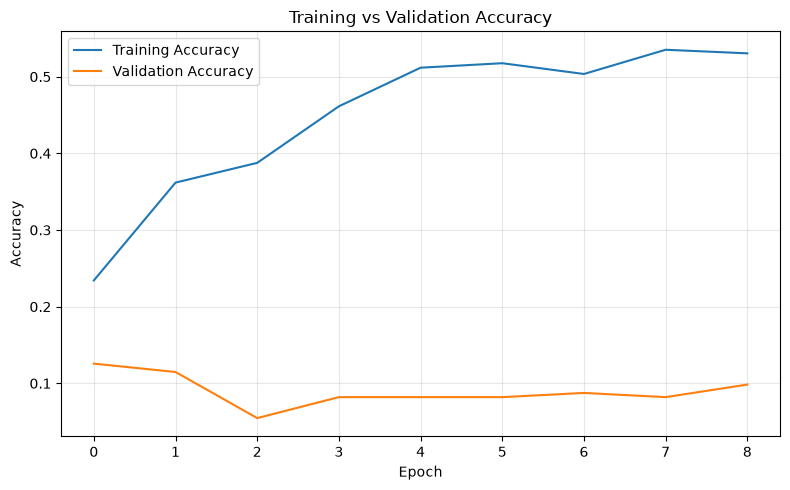

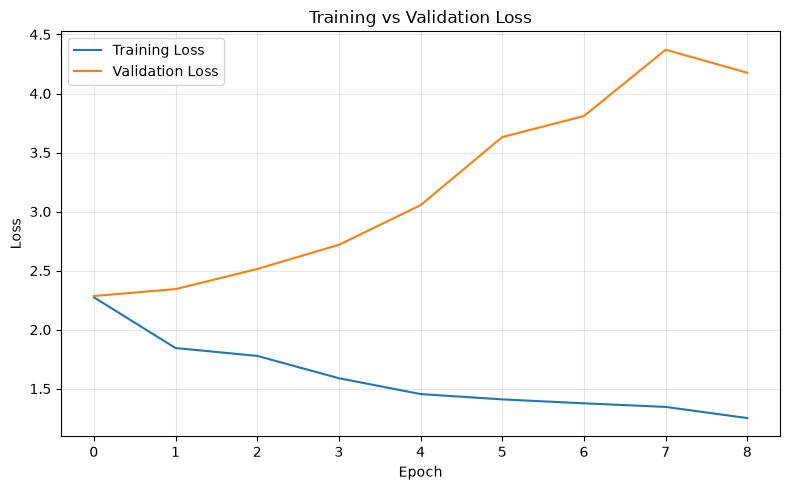

In [31]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Step 22 — CNN Model Comparison

In [32]:
configs = [
    {
        "name": "CNN_A",
        "dropout": 0.3,
        "filters": (16, 32),
        "lr": 1e-3
    },

    {
        "name": "CNN_B",
        "dropout": 0.5,
        "filters": (32, 64),
        "lr": 1e-3
    },

    {
        "name": "CNN_C",
        "dropout": 0.4,
        "filters": (16, 32),
        "lr": 1e-4
    }
]

variant_results = []

best_model = None
best_val_accuracy = -np.inf
best_config = None

for config in configs:

    print("\n" + "=" * 60)
    print("Training:", config["name"])
    print("=" * 60)

    variant_model = build_small_cnn(
        dropout=config["dropout"],
        filters=config["filters"],
        learning_rate=config["lr"]
    )

    variant_callbacks = [
        EarlyStopping(
            monitor="val_loss",
            patience=6,
            restore_best_weights=True
        )
    ]

    variant_history = variant_model.fit(
        train_datagen.flow(
            X_train,
            y_train,
            batch_size=BATCH_SIZE,
            shuffle=True,
            seed=SEED
        ),

        steps_per_epoch=int(
            np.ceil(len(X_train) / BATCH_SIZE)
        ),

        validation_data=(
            X_val,
            y_val
        ),

        epochs=40,

        callbacks=variant_callbacks,

        verbose=0
    )

    current_best = max(
        variant_history.history["val_accuracy"]
    )

    variant_results.append({
        "name": config["name"],
        "config": config,
        "best_val_accuracy": current_best
    })

    print(
        f"Best validation accuracy: "
        f"{current_best:.4f}"
    )

    # ----------------------------------------
    # Keep the BEST model
    # ----------------------------------------

    if current_best > best_val_accuracy:

        best_val_accuracy = current_best
        best_model = variant_model
        best_config = config


print("\n" + "=" * 60)
print("BEST MODEL")
print("=" * 60)

print("Model:", best_config["name"])
print("Configuration:", best_config)
print(
    "Best validation accuracy:",
    round(best_val_accuracy, 4)
)


Training: CNN_A
Best validation accuracy: 0.1913

Training: CNN_B
Best validation accuracy: 0.1694

Training: CNN_C
Best validation accuracy: 0.1311

BEST MODEL
Model: CNN_A
Configuration: {'name': 'CNN_A', 'dropout': 0.3, 'filters': (16, 32), 'lr': 0.001}
Best validation accuracy: 0.1913


## Step 23 — Variant Results

In [33]:

for result in variant_results:

    print(
        f"{result['name']}: "
        f"{result['best_val_accuracy']:.4f}"
    )

CNN_A: 0.1913
CNN_B: 0.1694
CNN_C: 0.1311


## Step 24 — FINAL TEST EVALUATION

In [34]:
final_model = best_model

test_loss, test_accuracy = final_model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print(
    f"Final Test Accuracy: "
    f"{test_accuracy:.4f}"
)

print(
    f"Final Test Loss: "
    f"{test_loss:.4f}"
)

Final Test Accuracy: 0.1311
Final Test Loss: 2.2866


## Step 25 — Predictions

In [35]:
y_pred_probs = final_model.predict(
    X_test,
    verbose=0
)

y_pred = np.argmax(
    y_pred_probs,
    axis=1
)

print("Predictions generated successfully. ✅")

Predictions generated successfully. ✅


## Step 26 — Classification Report

In [36]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=CLASSES,
        digits=4
    )
)

              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000        15
           1     0.0000    0.0000    0.0000        15
           2     0.0000    0.0000    0.0000        24
           3     0.0000    0.0000    0.0000        15
           4     0.0000    0.0000    0.0000        24
           5     0.1341    1.0000    0.2365        24
           6     0.0000    0.0000    0.0000        21
           7     0.0000    0.0000    0.0000        15
           8     0.0000    0.0000    0.0000        15
           9     0.0000    0.0000    0.0000        15

    accuracy                         0.1311       183
   macro avg     0.0134    0.1000    0.0236       183
weighted avg     0.0176    0.1311    0.0310       183



C:\Users\Hello\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Hello\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Hello\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

## Step 27 — Confusion Matrix

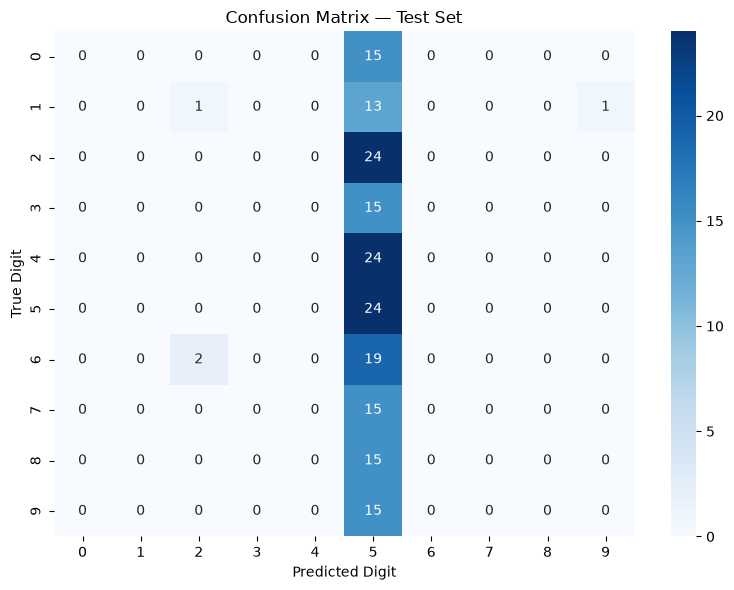

In [37]:
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASSES,
    yticklabels=CLASSES
)

plt.xlabel("Predicted Digit")
plt.ylabel("True Digit")
plt.title("Confusion Matrix — Test Set")

plt.tight_layout()
plt.show()

## Step 28 — Misclassified Images

Misclassified images: 159 / 183


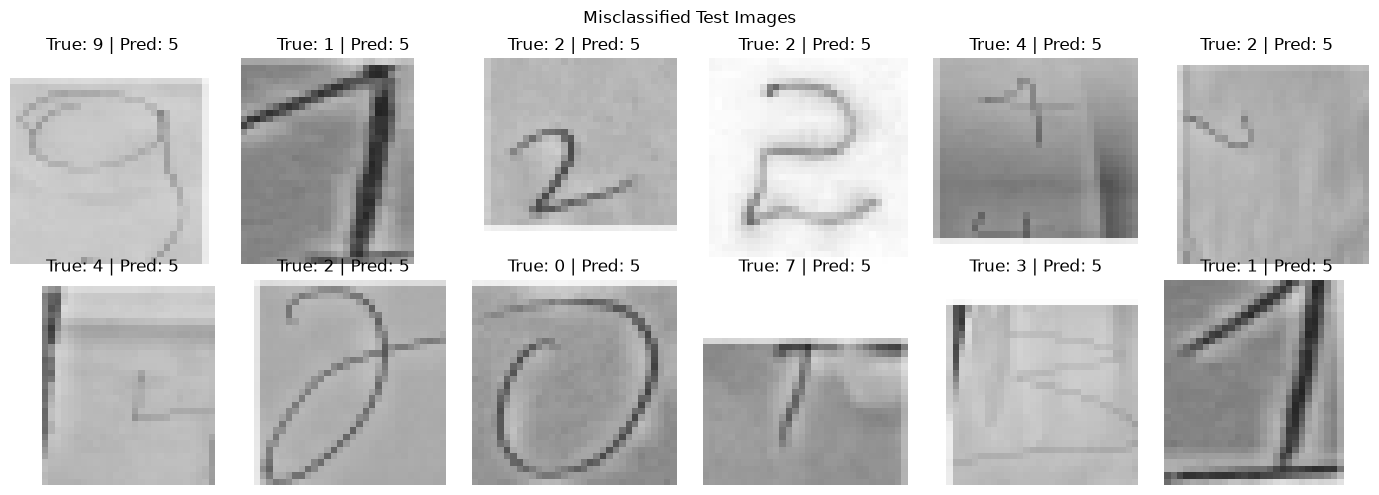

In [38]:
wrong_indices = np.where(
    y_pred != y_test
)[0]

print(
    f"Misclassified images: "
    f"{len(wrong_indices)} / {len(y_test)}"
)

if len(wrong_indices) > 0:

    n_show = min(
        12,
        len(wrong_indices)
    )

    fig, axes = plt.subplots(
        2,
        6,
        figsize=(14, 5)
    )

    axes = axes.flatten()

    for ax in axes:
        ax.axis("off")

    for ax, idx in zip(
        axes,
        wrong_indices[:n_show]
    ):

        ax.imshow(
            X_test[idx].squeeze(),
            cmap="gray",
            vmin=0,
            vmax=1
        )

        ax.set_title(
            f"True: {y_test[idx]} | "
            f"Pred: {y_pred[idx]}"
        )

        ax.axis("off")

    plt.suptitle(
        "Misclassified Test Images"
    )

    plt.tight_layout()
    plt.show()

else:

    print(
        "No misclassified test images. Excellent!"
    )

## Step 29 — Save Best Model

In [39]:
MODEL_PATH = "digit_recognition_model.keras"

final_model.save(
    MODEL_PATH
)

print(
    f"Best model saved to: {MODEL_PATH}"
)

Best model saved to: digit_recognition_model.keras


## Step 30 — Reload Saved Model

In [40]:

loaded_model = tf.keras.models.load_model(
    MODEL_PATH
)

print("Saved model loaded successfully. ✅")

Saved model loaded successfully. ✅


## Step 31 — Verify Loaded Model

In [41]:
loaded_test_loss, loaded_test_accuracy = (
    loaded_model.evaluate(
        X_test,
        y_test,
        verbose=0
    )
)

print(
    f"Loaded model test accuracy: "
    f"{loaded_test_accuracy:.4f}"
)

Loaded model test accuracy: 0.1311


## Step 32 — Prediction Function

In [42]:
def predict_digit_from_path(
    path,
    model=loaded_model
):

    processed = preprocess_image(
        path
    )

    if processed is None:

        print(
            "Could not read image:"
        )

        print(path)

        return None

    # Add batch + channel dimensions
    batch = processed.reshape(
        1,
        IMG_SIZE,
        IMG_SIZE,
        1
    )

    probabilities = model.predict(
        batch,
        verbose=0
    )[0]

    prediction = int(
        np.argmax(probabilities)
    )

    confidence = float(
        probabilities[prediction]
    )

    plt.figure(figsize=(3, 3))

    plt.imshow(
        processed,
        cmap="gray",
        vmin=0,
        vmax=1
    )

    plt.title(
        f"Predicted: {prediction}\n"
        f"Confidence: {confidence:.2%}"
    )

    plt.axis("off")
    plt.show()

    return prediction, probabilities

## Step 33 — Upload Prediction Interface

In [55]:
import ipywidgets as widgets
from IPython.display import display, clear_output

upload_widget = widgets.FileUpload(
    accept="image/*",
    multiple=False,
    description="Upload Digit"
)

output = widgets.Output()


def on_upload_change(change):

    with output:

        clear_output()

        if not upload_widget.value:
            return

        # ipywidgets 8
        if isinstance(
            upload_widget.value,
            dict
        ):

            item = list(
                upload_widget.value.values()
            )[0]

        # Older ipywidgets
        else:

            item = upload_widget.value[0]

        content = item["content"]

        temp_path = (
            "uploaded_digit.jpg"
        )

        with open(
            temp_path,
            "wb"
        ) as file:

            file.write(content)

        predict_digit_from_path(
            temp_path
        )


upload_widget.observe(
    on_upload_change,
    names="value"
)

display(
    upload_widget,
    output
)

FileUpload(value=(), accept='image/*', description='Upload Digit')

Output()

## Step 34 — Deployment Sanity Test

Testing with: ../digit_dataset\5\5_001.jpg


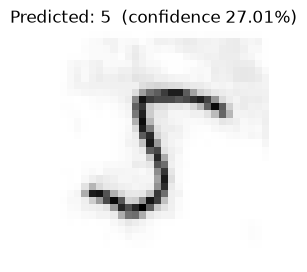

In [57]:
sample_test_files = (
    glob.glob(
        os.path.join(
            DATASET_DIR,
            "5",
            "*.jpg"
        )
    )
)

if sample_test_files:

    sample_test_path = (
        sample_test_files[0]
    )

    print(
        "Testing with:",
        sample_test_path
    )

    predict_digit_from_path(
        sample_test_path
    )

else:

    print(
        "No test image found."
    )